#Laboratorio 2
##Nombre: Carlos Alberto Aucu Gomez

#Problema
Eres parte de un equipo que desarrolla un sistema de logistica de entregas en una ciudad. Tienes coordenadas (x,y) de 10.000 puntos de entrega (estos datos los puedes tomar de datos reales o generarlos, para este ejercicio los dados son estaticos, no cambian)

Necesitas implementar un sistema que responda eficientemente preguntas como:
- ¿Que puntos de entrega estan a un radio de 500 metros de un punto dado? (tener en cuenta unidades)
- ¿Cual es o son los puntos de entrega mas cercano a una ubicacion dada?

##Objetivo: implementar un Arbol-KD desde cero, y comparar con fuerza bruta.

##Micro-tareas para resolver el ejercicio:
- Construir el Arbol-KD (no se pueden usar arboles ya generados o librerias como scipy)
- Implementar busqueda dentro de un radio (Range Search)
- Vecinos (puntos encontrados dentro del radio) y encontrar los mas cercanos
- Verificacion visual de radio y puntos encontrados dentro del radio
- Verificacion visual de los vecinos mas cercanos.
- IMPORTANTE: trate de hacer el codigo para K-dimensiones, sino, puede ser solo para 2D
- No se permiten soluciones completas de internet o vibe coding, si se puede apoyar de IA o internet



#Codigo:

#Generar los datos y el nodo del arbol
Para simular la ciudad, generamos 10.000 puntos aleatorios dentro de un área de 10 km × 10 km. Las coordenadas están en metros, lo que significa que un "radio de 500" equivale a 500 metros reales para evitar conversiones innecesarias durante las búsquedas.

In [30]:
import random
import math

#1. generar datos
random.seed(42)

num_puntos = 10000
ciudad_m = 10000

puntos = [(random.uniform(0, ciudad_m), random.uniform(0, ciudad_m)) for _ in range(num_puntos) ]


Cada punto de entrega vive en un Nodo. Un Nodo es simplemente guarda tres cosas: el punto en sí (sus coordenadas), un hijo izquierdo y un hijo derecho. Esos hijos son a su vez otros Nodos, y así se forma el árbol.

In [31]:
#2. nodo del arbol
class Nodo:
    def __init__(self, punto, izquierda=None, derecha=None):
        self.punto = punto
        self.izquierda = izquierda # sub-arbol con puntos menores
        self.derecha = derecha # sub-arbol con puntos mayores

#Crear el Arbol-KD
La construcción se basa en dividir para organizar. En cada paso tomamos todos los puntos que tenemos, los ordenamos por uno de los ejes (primero por X, luego por Y, luego por X de nuevo, alternando), y el punto del medio (la mediana) se convierte en el Nodo de ese nivel. Los puntos a la izquierda de la mediana forman el subárbol izquierdo, y los de la derecha forman el subárbol derecho.

El resultado es un árbol donde el espacio queda dividido en regiones, como un sistema de carpetas dentro de carpetas. Esto es lo que permite después descartar zonas enteras durante una búsqueda sin tener que revisarlas.

Tres cosas importantes del diseño:

* Alternar entre ejes: se divide primero por X, luego por Y, luego por X, y así sucesivamente. Esto garantiza que el árbol organice el espacio en todas las direcciones.
* Usar la mediana: al cortar siempre por el punto del medio, el árbol queda balanceado, con aproximadamente la misma cantidad de puntos en cada lado.
* Recursión: el mismo proceso se repite en cada mitad hasta que no quedan puntos.

In [32]:
# 3. Árbol-KD

def calcular_mediana(puntos_ordenados, eje):
    n = len(puntos_ordenados)

    if n % 2 == 1:
        # si la cantidad de puntos es impar, la mediana es el val del elem central
        return puntos_ordenados[n // 2][eje]
    else:
        # si la cantidad de puntos es par, La mediana es el promedio de los dos val del centro.
        val1 = puntos_ordenados[n // 2 - 1][eje]
        val2 = puntos_ordenados[n // 2][eje]
        return (val1 + val2) / 2


def construir_kdtree(puntos, profundidad=0):
    if not puntos:          # lista vacía → no hay nodo
        return None

    k   = len(puntos[0])   # num de dim
    eje = profundidad % k  # alterna 0=x, 1=y, 0=x ...

    # ordenar los puntos según el eje actual para que los valores queden
    # de mayor a menor en ese eje
    puntos_ordenados = sorted(puntos, key=lambda p: p[eje])

    # calcular el VALOR de la mediana real en ese eje
    # Esto funciona con cualquier distribución de datos porque
    # si los datos estan concentrados en una zona, la mediana
    # seguira dividiendo la lista
    mediana_valor = calcular_mediana(puntos_ordenados, eje)

    # encontrar la POSICIÓN del punto cuyo valor en el eje
    # es el más cercano al valor de la mediana calculada.

    indice_mediana = min(
        range(len(puntos_ordenados)),
        key=lambda i: abs(puntos_ordenados[i][eje] - mediana_valor)
    )

    return Nodo(
        punto     = puntos_ordenados[indice_mediana],
        izquierda = construir_kdtree(puntos_ordenados[:indice_mediana],      profundidad + 1),
        derecha   = construir_kdtree(puntos_ordenados[indice_mediana + 1:],  profundidad + 1)
    )

In [ ]:
#Prueba
raiz = construir_kdtree(puntos)
print(f"Raiz: {raiz.punto}")
print(f"Raiz izquierda: {raiz.izquierda.punto}")
print(f"Raiz derecha: {raiz.derecha.punto}")

#Busqueda por radio (Range Search)

Dado un punto de consulta y un radio (por ejemplo 500 metros), queremos encontrar todos los puntos del árbol que estén dentro de ese círculo.
La búsqueda recorre el árbol de arriba hacia abajo, igual que se construyó. En cada Nodo hace dos cosas:
Primero, mide la distancia entre el punto de consulta y el punto del Nodo. Si esa distancia es menor o igual al radio, lo agrega a los resultados.
Segundo y mas importante, decide si vale la pena seguir buscando en los subárboles.

Aquí entra lo que se llama la poda (backtracking): en cada Nodo existe un plano de corte (la línea imaginaria que dividió los puntos al construir el árbol). Si el círculo de búsqueda no alcanza a cruzar ese plano, entonces todos los puntos del otro lado están definitivamente fuera del radio, y se pueden ignorar por completo sin revisarlos.

In [34]:
#5 distancia entre dos puntos
def distancia(p1, p2):
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(p1, p2)))

#6 busqueda por radio
def busqueda_radio(nodo, consulta, radio, profundidad=0, encontrados=None):
    if encontrados is None:
        encontrados = []

    if nodo is None:
        return []

    if distancia(consulta, nodo.punto) <= radio: #el punto del nodo esta en el radio?
        encontrados.append(nodo.punto)

    # podar del kdtree
    k = len(consulta)
    eje = profundidad % k
    distancia_al_plano = consulta[eje] - nodo.punto[eje]

    # si la dist al plano es negativa, la consulta esta a la izq
    #si la dist al plano es positiva, la consulta esta a la der

    if distancia_al_plano <= 0:
        lado_cercano = nodo.izquierda
        lado_lejano = nodo.derecha
    else:
        lado_cercano = nodo.derecha
        lado_lejano = nodo.izquierda

    #explorar el lado mas cercano
    busqueda_radio(lado_cercano, consulta, radio, profundidad+1, encontrados)


    #solo se explora el lado lejano si el circulo cruza el plano
    #(si la distancia al plano es menor que el radio)

    if abs(distancia_al_plano) <= radio:
        busqueda_radio(lado_lejano, consulta, radio, profundidad+1, encontrados)

    return encontrados


In [ ]:
"""
#Prueba
"""
punto_consulta = (3000, 3000)
radio_busqueda = 500
resultados = busqueda_radio(raiz, punto_consulta, radio_busqueda)
print(f"Puntos encontrados dentro del radio {radio_busqueda}: {resultados}")
print(f"Primeros 3: {resultados[:3]}")


#Vecinos (puntos encontrados dentro del radio) y encontrar los mas cercanos

Aquí el objetivo es encontrar el único punto más cercano al punto de consulta, sin importar a qué distancia esté.
La lógica es casi idéntica a la búsqueda por radio unicamente que no hay un radio fijo.

En cambio, se considera un "mejor candidato" que se actualiza durante el recorrido. Al principio, ese candidato tiene distancia infinita. Cada vez que encontramos un punto más cercano que el actual se reemplaza.
La poda funciona igual, pero usando la distancia al mejor candidato como radio dinámico. Conforme encontramos puntos más cercanos, ese radio se va achicando, y podemos descartar cada vez más subárboles. Al final del recorrido, el mejor candidato es el vecino más cercano.

In [36]:
#7 vecino mas cercano
def vecino_mas_cercano(nodo, consulta, profundidad=0, mejor=None):

    if mejor is None:
        mejor = [None, float('inf')] #punto mas cercano, su dist

    if nodo is None:
        return mejor

    dist_actual = distancia(consulta, nodo.punto)

    if dist_actual < mejor[1]:
        mejor[0] = nodo.punto
        mejor[1] = dist_actual

    # misma logica de podar que por radio
    k = len(consulta)
    eje = profundidad % k
    distancia_al_plano = consulta[eje] - nodo.punto[eje]

    if distancia_al_plano <= 0:
        lado_cercano = nodo.izquierda
        lado_lejano = nodo.derecha
    else:
        lado_cercano = nodo.derecha
        lado_lejano = nodo.izquierda

    #explorar primero el lado cercano
    vecino_mas_cercano(lado_cercano, consulta, profundidad+1, mejor)
    #solo se explora el lado lejano si contiene un punto mas cercano que el mejor actual
    if abs(distancia_al_plano) < mejor[1]:
        vecino_mas_cercano(lado_lejano, consulta, profundidad+1, mejor)

    return mejor


In [ ]:
"""
#Prueba
"""
punto_consulta = (3000, 3000)
resultado= vecino_mas_cercano(raiz, punto_consulta)
punto_cercano = resultado[0]
distancia_cercana = resultado[1]
print(f"punto de consulta: {punto_consulta}")
print(f"punto mas cercano: {punto_cercano}")
print(f"distancia al punto mas cercano: {distancia_cercana:.2f} metros")


#Visualización


##Verificacion visual de radio y puntos encontrados dentro del radio.

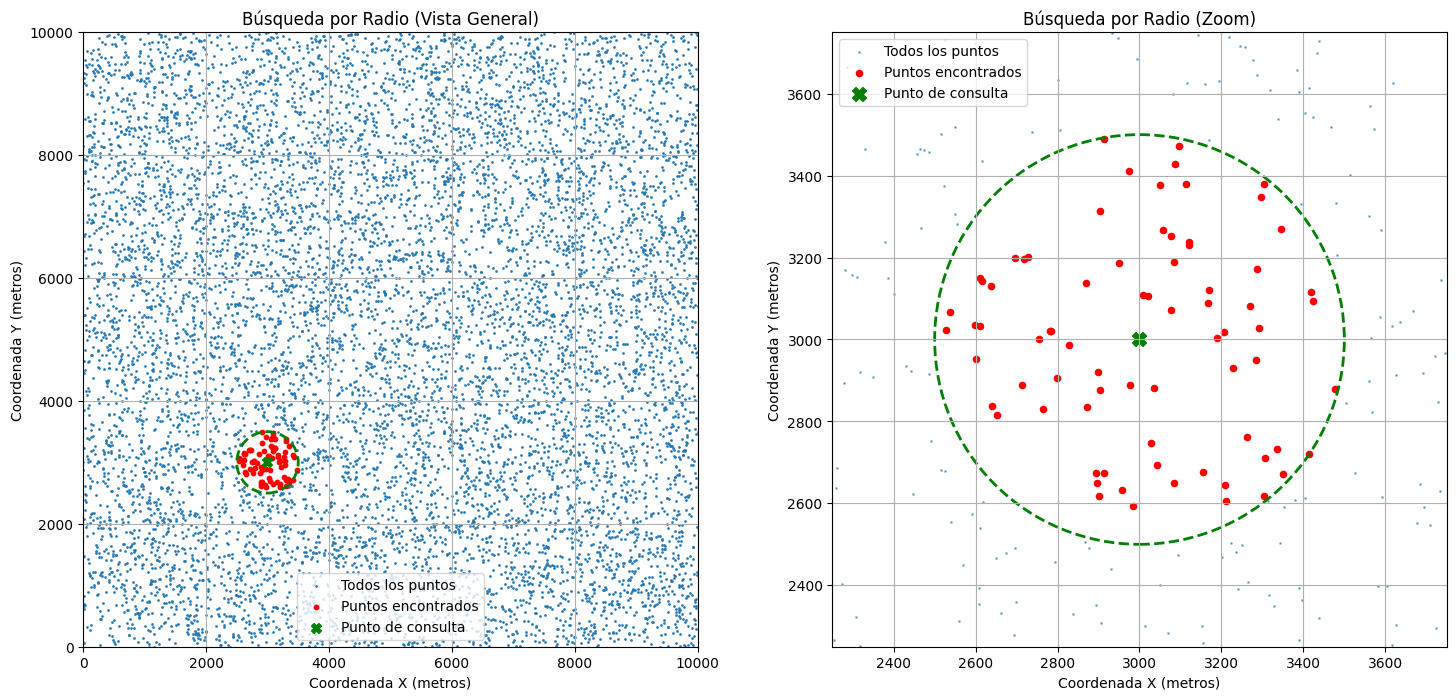

In [38]:
import matplotlib.pyplot as plt

def visualizar_busqueda_radio(puntos_totales, punto_consulta, radio_busqueda, puntos_encontrados, ciudad_m):
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))

    # Gráfica General
    # Extraer coordenadas para graficar
    x_totales = [p[0] for p in puntos_totales]
    y_totales = [p[1] for p in puntos_totales]
    x_encontrados = [p[0] for p in puntos_encontrados]
    y_encontrados = [p[1] for p in puntos_encontrados]

    axs[0].scatter(x_totales, y_totales, s=1, alpha=0.9, label='Todos los puntos')
    axs[0].scatter(x_encontrados, y_encontrados, s=10, color='red', label='Puntos encontrados')
    axs[0].scatter(punto_consulta[0], punto_consulta[1], s=50, color='green', marker='X', label='Punto de consulta')

    # Dibujar el círculo de búsqueda
    circle = plt.Circle(punto_consulta, radio_busqueda, color='green', fill=False, linestyle='--', linewidth=2)
    axs[0].add_patch(circle)

    axs[0].set_title('Búsqueda por Radio (Vista General)')
    axs[0].set_xlabel('Coordenada X (metros)')
    axs[0].set_ylabel('Coordenada Y (metros)')
    axs[0].set_xlim(0, ciudad_m)
    axs[0].set_ylim(0, ciudad_m)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].legend()
    axs[0].grid(True)

    # Gráfica con Zoom
    axs[1].scatter(x_totales, y_totales, s=1, alpha=0.5, label='Todos los puntos')
    axs[1].scatter(x_encontrados, y_encontrados, s=20, color='red', label='Puntos encontrados')
    axs[1].scatter(punto_consulta[0], punto_consulta[1], s=100, color='green', marker='X', label='Punto de consulta')

    # Dibujar el círculo de búsqueda
    circle_zoom = plt.Circle(punto_consulta, radio_busqueda, color='green', fill=False, linestyle='--', linewidth=2)
    axs[1].add_patch(circle_zoom)

    axs[1].set_title('Búsqueda por Radio (Zoom)')
    axs[1].set_xlabel('Coordenada X (metros)')
    axs[1].set_ylabel('Coordenada Y (metros)')
    # Definir límites del zoom alrededor del punto de consulta y el radio
    zoom_margin = radio_busqueda * 1.5 # Un poco más grande que el radio para mejor visualización
    axs[1].set_xlim(punto_consulta[0] - zoom_margin, punto_consulta[0] + zoom_margin)
    axs[1].set_ylim(punto_consulta[1] - zoom_margin, punto_consulta[1] + zoom_margin)
    axs[1].set_aspect('equal', adjustable='box')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Prueba de visualización
# Asegurarse de que `puntos`, `punto_consulta`, `radio_busqueda`, `resultados` y `ciudad_km` estén definidos
visualizar_busqueda_radio(puntos, punto_consulta, radio_busqueda, resultados, ciudad_m)


##Verificacion visual de los vecinos mas cercanos.

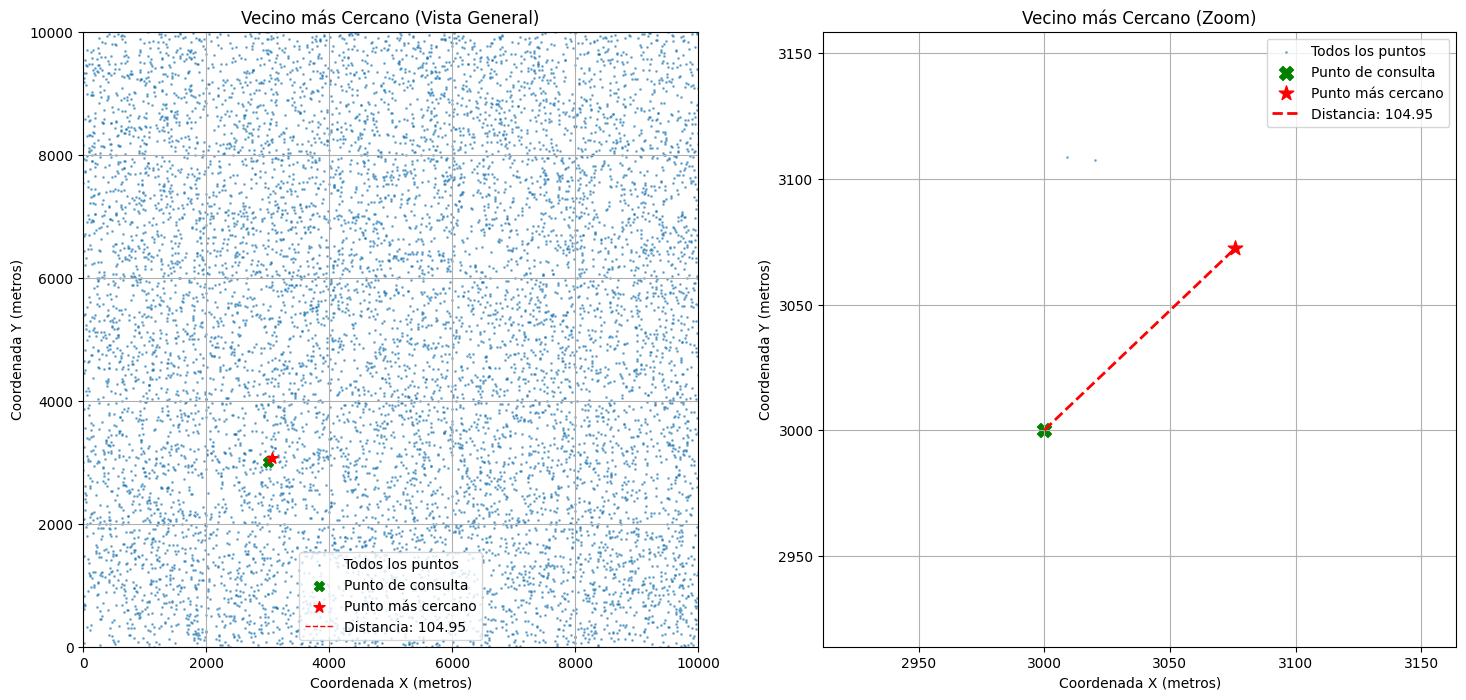

In [39]:
def visualizar_vecino_mas_cercano(puntos_totales, punto_consulta, punto_cercano, distancia_cercana, ciudad_m):
    fig, axs = plt.subplots(1, 2, figsize=(15, 7))

    # Gráfica General
    x_totales = [p[0] for p in puntos_totales]
    y_totales = [p[1] for p in puntos_totales]

    axs[0].scatter(x_totales, y_totales, s=1, alpha=0.5, label='Todos los puntos')
    axs[0].scatter(punto_consulta[0], punto_consulta[1], s=50, color='green', marker='X', label='Punto de consulta')
    axs[0].scatter(punto_cercano[0], punto_cercano[1], s=70, color='red', marker='*', label='Punto más cercano')
    axs[0].plot([punto_consulta[0], punto_cercano[0]], [punto_consulta[1], punto_cercano[1]], color='red', linestyle='--', linewidth=1, label=f'Distancia: {distancia_cercana:.2f}')

    axs[0].set_title('Vecino más Cercano (Vista General)')
    axs[0].set_xlabel('Coordenada X (metros)')
    axs[0].set_ylabel('Coordenada Y (metros)')
    axs[0].set_xlim(0, ciudad_m)
    axs[0].set_ylim(0, ciudad_m)
    axs[0].set_aspect('equal', adjustable='box')
    axs[0].legend()
    axs[0].grid(True)

    # Gráfica con Zoom
    axs[1].scatter(x_totales, y_totales, s=1, alpha=0.5, label='Todos los puntos')
    axs[1].scatter(punto_consulta[0], punto_consulta[1], s=100, color='green', marker='X', label='Punto de consulta')
    axs[1].scatter(punto_cercano[0], punto_cercano[1], s=120, color='red', marker='*', label='Punto más cercano')
    axs[1].plot([punto_consulta[0], punto_cercano[0]], [punto_consulta[1], punto_cercano[1]], color='red', linestyle='--', linewidth=2, label=f'Distancia: {distancia_cercana:.2f}')

    axs[1].set_title('Vecino más Cercano (Zoom)')
    axs[1].set_xlabel('Coordenada X (metros)')
    axs[1].set_ylabel('Coordenada Y (metros)')

    # Definir límites del zoom alrededor del punto de consulta y el punto más cercano
    min_x = min(punto_consulta[0], punto_cercano[0])
    max_x = max(punto_consulta[0], punto_cercano[0])
    min_y = min(punto_consulta[1], punto_cercano[1])
    max_y = max(punto_consulta[1], punto_cercano[1])

    # Añadir un margen al zoom
    zoom_margin_x = abs(max_x - min_x) * 0.5 + 50 # Añadir un margen fijo de 50 si la distancia es muy pequeña
    zoom_margin_y = abs(max_y - min_y) * 0.5 + 50

    axs[1].set_xlim(min_x - zoom_margin_x, max_x + zoom_margin_x)
    axs[1].set_ylim(min_y - zoom_margin_y, max_y + zoom_margin_y)

    axs[1].set_aspect('equal', adjustable='box')
    axs[1].legend()
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

# Prueba de visualización
# Asegurarse de que `puntos`, `punto_consulta`, `punto_cercano`, `distancia_cercana` y `ciudad_km` estén definidos
visualizar_vecino_mas_cercano(puntos, punto_consulta, punto_cercano, distancia_cercana, ciudad_m)


#Analisis comparativo:
¿Para que tamaño de datos el arbol-KD comienza a ser mas rapido que "fuerza bruta" (no arboles, si listas, ...)?

La fuerza bruta simplemente recorre todos los puntos uno por uno y calcula la distancia a cada uno. Es la solución más directa posible.
Sirve para dos cosas en este laboratorio. Primero, verificar que el KD-Tree está dando los resultados correctos: ambos métodos deben encontrar exactamente los mismos puntos. Segundo, medir la diferencia de velocidad entre los dos enfoques.



In [40]:
import timeit

# --- Brute Force Range Search ---
def busqueda_radio_fuerza_bruta(puntos, consulta, radio):
    encontrados_fb = []
    for p in puntos:
        if distancia(consulta, p) <= radio:
            encontrados_fb.append(p)
    return encontrados_fb

# --- Brute Force Nearest Neighbor Search ---
def vecino_mas_cercano_fuerza_bruta(puntos, consulta):
    mejor_punto = None
    menor_distancia = float('inf')
    for p in puntos:
        dist = distancia(consulta, p)
        if dist < menor_distancia:
            menor_distancia = dist
            mejor_punto = p
    return mejor_punto, menor_distancia


In [41]:
num_puntos_pruebas = [5, 10, 100, 500, 1000, 5000, 10000]

tiempos_kdtree_range = []
tiempos_bruteforce_range = []
tiempos_kdtree_nn = []
tiempos_bruteforce_nn = []

ciudad_km_test = 10000
radio_busqueda_grafico = ciudad_km_test * 0.05 # Radio de búsqueda relativo al tamaño de la ciudad

for n in num_puntos_pruebas:

    # Generar puntos aleatorios para el tamaño actual
    random.seed(42) # Para reproducibilidad
    puntos_test = [(random.uniform(0, ciudad_km_test), random.uniform(0, ciudad_km_test)) for _ in range(n)]

    # Construir KD-Tree para los puntos actuales
    raiz_test = construir_kdtree(puntos_test)

    # Punto de consulta en el centro para ser representativo
    punto_consulta_grafico = (ciudad_km_test / 2, ciudad_km_test / 2)

    # --- Medir tiempo para Búsqueda por Radio ---
    setup_kdtree_range_loop = f"""from __main__ import raiz_test, busqueda_radio, punto_consulta_grafico, radio_busqueda_grafico"""
    time_kdtree_range_val = timeit.timeit("busqueda_radio(raiz_test, punto_consulta_grafico, radio_busqueda_grafico)", setup=setup_kdtree_range_loop, number=10)
    tiempos_kdtree_range.append(time_kdtree_range_val)

    setup_bruteforce_range_loop = f"""from __main__ import puntos_test, busqueda_radio_fuerza_bruta, punto_consulta_grafico, radio_busqueda_grafico"""
    time_bruteforce_range_val = timeit.timeit("busqueda_radio_fuerza_bruta(puntos_test, punto_consulta_grafico, radio_busqueda_grafico)", setup=setup_bruteforce_range_loop, number=10)
    tiempos_bruteforce_range.append(time_bruteforce_range_val)

    # --- Medir tiempo para Vecino Más Cercano ---
    setup_kdtree_nn_loop = f"""from __main__ import raiz_test, vecino_mas_cercano, punto_consulta_grafico"""
    time_kdtree_nn_val = timeit.timeit("vecino_mas_cercano(raiz_test, punto_consulta_grafico)", setup=setup_kdtree_nn_loop, number=10)
    tiempos_kdtree_nn.append(time_kdtree_nn_val)

    setup_bruteforce_nn_loop = f"""from __main__ import puntos_test, vecino_mas_cercano_fuerza_bruta, punto_consulta_grafico"""
    time_bruteforce_nn_val = timeit.timeit("vecino_mas_cercano_fuerza_bruta(puntos_test, punto_consulta_grafico)", setup=setup_bruteforce_nn_loop, number=10)
    tiempos_bruteforce_nn.append(time_bruteforce_nn_val)

print("Datos comparativos recolectados.")

Datos comparativos recolectados.


### Gráfico Comparativo de Tiempos de Ejecución (KD-Tree vs. Fuerza Bruta)

In [ ]:
import pandas as pd

datos_comparativos = {
    'Número de Puntos': num_puntos_pruebas,
    'KD-Tree (Range Search)': tiempos_kdtree_range,
    'Fuerza Bruta (Range Search)': tiempos_bruteforce_range,
    'KD-Tree (Vecino Más Cercano)': tiempos_kdtree_nn,
    'Fuerza Bruta (Vecino Más Cercano)': tiempos_bruteforce_nn
}

df_comparativo = pd.DataFrame(datos_comparativos)

# Redondear los tiempos para una mejor lectura
for col in df_comparativo.columns:
    if 'Tiempo' in col or 'Search' in col or 'Cercano' in col:
        df_comparativo[col] = df_comparativo[col].round(6)

print("Tabla Comparativa de Tiempos de Ejecución (segundos):")
display(df_comparativo)

Tabla Comparativa de Tiempos de Ejecución (segundos):


,Número de Puntos,KD-Tree (Range Search),Fuerza Bruta (Range Search),KD-Tree (Vecino Más Cercano),Fuerza Bruta (Vecino Más Cercano)
0,5,0.000051,0.000038,0.000058,0.000057
1,10,0.000033,0.000071,0.000069,0.000067
2,100,0.000105,0.000656,0.000129,0.000622
3,500,0.000355,0.003154,0.000303,0.003114
4,1000,0.000411,0.006260,0.000263,0.007932
5,5000,0.000913,0.039193,0.000349,0.037135
6,10000,0.001409,0.073373,0.000271,0.074535


La tabla muestran que el KD-Tree es más rápido que fuerza bruta incluso desde cantidades pequeñas de datos como 1.000 puntos o menos.
Esto ocurre porque la fuerza bruta siempre revisa todos los puntos, es decir, si se tienen el doble de puntos tarda el doble.
El KD-Tree descarta subárboles enteros. Con 1.000 puntos, en lugar de revisar los 1.000, puede resolver la consulta revisando solo unos 10 o 15 nodos. Con 10.000 puntos, revisa tal vez 15 o 20. El trabajo crece muy lentamente aunque los datos crezcan mucho.

Sin embargo, el KD-Tree tiene un costo inicial porque construir el árbol toma tiempo. Si solo se va a hacer una consulta, puede que fuerza bruta sea más rápida en total porque no tiene ese costo previo.
El KD-Tree vale la pena cuando se van a hacer muchas consultas sobre los mismos datos. En ese caso, el costo de construir el árbol se reparte entre todas las consultas, y la ganancia de velocidad en cada una de ellas compensa ampliamente ese costo inicial.

En conclusión, se puede evidenciar en la tabla que en valores pequeños como 5, la fuerza bruta es mas rapida en tiempo de ejecuciones que el arbol-kd, pero a partir de valores mas grandes como 100, el arbol-kd comienza a ser mas rapido que la fuerza bruta.